<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [25]:
# Check for GPU
!nvidia-smi

Mon Jun 23 14:17:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.76                 Driver Version: 572.76         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 4000              WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   54C    P8             12W /  110W |     352MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [26]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

2.7.1+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [27]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transformer = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root='./data/',
                            train=True,
                            download=True,
                            transform=transformer)

test_data = datasets.MNIST(root='./data/',
                           train=False,
                           download=True,
                           transform=transformer)

## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [28]:
import random

k = random.choice(train_data)
k[0].shape

torch.Size([1, 28, 28])

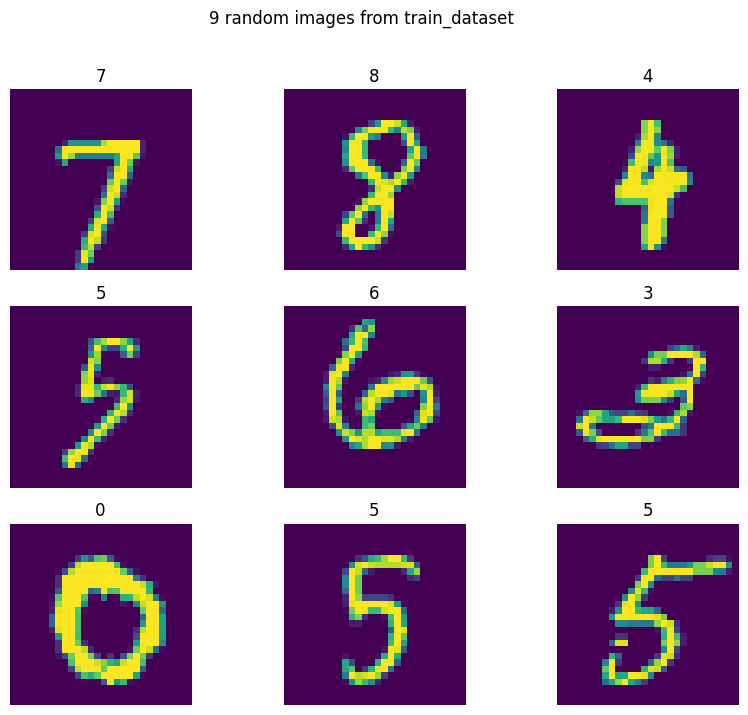

In [29]:
import matplotlib.pyplot as plt
import random

n=9
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10,8))
ax = ax.flatten()
for i in range(n):
    img, label = random.choice(train_data)
    ax[i].imshow(img.squeeze())
    ax[i].set_title(f"{label}")
    ax[i].grid(False)
    ax[i].set_axis_off()

plt.suptitle("9 random images from train_dataset")
plt.show()



## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [30]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data,
                              batch_size=32,
                              shuffle=True)
test_dataloader = DataLoader(test_data,
                             batch_size=32,
                             shuffle=True)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [31]:
img.shape

torch.Size([1, 28, 28])

In [32]:
from torch import nn

class TinyVGG(nn.Module):
    def __init__(self, input_neurons, hidden_units, output_neurons):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_neurons,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding= 1,
                      stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.AdaptiveAvgPool1d(hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=output_neurons)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [33]:
# To train the model, Identify the loss function, accuracy, and optimizers first
import torch.optim.optimizer
from torchmetrics import Accuracy


loss_fn = nn.CrossEntropyLoss()

accuracy_fn = Accuracy(task='multiclass',
                       num_classes=10)




In [34]:
def train_model(model, device, accuracy_fn):
    model = model.to(device)
    optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.01)
    accuracy_fn = accuracy_fn.to(device)
    epochs = 5
    train_loss_list, test_loss_list = [], []
    train_acc_list, test_acc_list = [], []
    for epoch in range(epochs):
        train_loss_value, test_loss_value = 0, 0
        model.train()
        for X, y in train_dataloader:
            # forward pass
            X, y = X.to(device), y.to(device)
            pred_logits = model(X)

            train_loss = loss_fn(pred_logits, y) #calcualte the loss
            train_loss_value += train_loss.item()

            accuracy_fn.update(pred_logits, y) #queque in the results to calculate the accuracy

            optimizer.zero_grad() # zero the gradients

            train_loss.backward() # back propagate

            optimizer.step() # step against the gradient
        
        train_loss_value /= len(train_dataloader)
        train_loss_list.append(train_loss_value)
        train_acc_value = accuracy_fn.compute()
        accuracy_fn.reset()
        train_acc_list.append(train_acc_value)
        
        model.eval()
        with torch.inference_mode():
            for X, y in test_dataloader:
                X, y = X.to(device), y.to(device)
                pred_logits = model(X)
                test_loss_value += loss_fn(pred_logits, y).item()

                accuracy_fn.update(pred_logits, y)
        
        test_loss_value /= len(test_dataloader)
        test_loss_list.append(test_loss_value)
        test_acc_value = accuracy_fn.compute()
        accuracy_fn.reset()
        test_acc_list.append(test_acc_value)

        print(f"Epoch: {epoch} | Train Loss: {train_loss_value:0.4f} | Train Accuracy: {train_acc_value:.4f} | Test Loss: {test_loss_value:.4f} | Test Accuracy: {test_acc_value:.4f}")

In [35]:
from timeit import default_timer
model_0 = TinyVGG(input_neurons=1, hidden_units=20, output_neurons=10)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
start = default_timer()
train_model(model_0, device, accuracy_fn)
end = default_timer()
print(f"Time taken for training the model on {device}: {end-start} seconds")

Epoch: 0 | Train Loss: 2.2964 | Train Accuracy: 0.1352 | Test Loss: 2.2741 | Test Accuracy: 0.1401
Epoch: 1 | Train Loss: 2.2343 | Train Accuracy: 0.1780 | Test Loss: 2.1523 | Test Accuracy: 0.2119
Epoch: 2 | Train Loss: 1.8817 | Train Accuracy: 0.3129 | Test Loss: 1.4643 | Test Accuracy: 0.5014
Epoch: 3 | Train Loss: 0.9219 | Train Accuracy: 0.6939 | Test Loss: 0.5378 | Test Accuracy: 0.8334
Epoch: 4 | Train Loss: 0.4067 | Train Accuracy: 0.8775 | Test Loss: 0.2752 | Test Accuracy: 0.9184
Time taken for training the model on cuda: 66.32119129999955 seconds


In [36]:

model_1 = TinyVGG(input_neurons=1, hidden_units=20, output_neurons=10)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
start = default_timer()
train_model(model_1, device, accuracy_fn)
end = default_timer()
print(f"Time taken for training the model on {device}: {end-start} seconds")

Epoch: 0 | Train Loss: 2.3037 | Train Accuracy: 0.1032 | Test Loss: 2.3009 | Test Accuracy: 0.1135
Epoch: 1 | Train Loss: 2.3003 | Train Accuracy: 0.1124 | Test Loss: 2.2986 | Test Accuracy: 0.1135
Epoch: 2 | Train Loss: 2.2893 | Train Accuracy: 0.1505 | Test Loss: 2.2625 | Test Accuracy: 0.1808
Epoch: 3 | Train Loss: 2.0774 | Train Accuracy: 0.2407 | Test Loss: 1.9363 | Test Accuracy: 0.2769
Epoch: 4 | Train Loss: 1.5813 | Train Accuracy: 0.4375 | Test Loss: 1.1315 | Test Accuracy: 0.5690
Time taken for training the model on cuda: 66.37841560000015 seconds


In [ ]:
model_2 = TinyVGG(input_neurons=1, hidden_units=20, output_neurons=10)
device='cpu'
start = default_timer()
train_model(model_2, device, accuracy_fn)
end = default_timer()
print(f"Time taken for training the model on {device}: {end-start} seconds")

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [ ]:
model_2(test_data[0][0].unsqueeze(0)).argmax(dim=1)

In [ ]:
test_data[0][0].shape

In [ ]:
t = [(1,3),(2,4),(12,14)]
for x,y in t:
    print(x, y)

In [ ]:
# I am particulary interested in visualization of the wrong predictions

import random
def visualize_wrong_pred(model, device):
    model = model.to(device)
    wrong_pred_idx = []
    for i, (X, y) in enumerate(test_data):
        X = X.to(device)
        with torch.inference_mode():
            pred_logits = model(X.unsqueeze(0))
            if y != pred_logits.argmax(dim=1).item():
                wrong_pred_idx.append((i, pred_logits.argmax(dim=1).item()))
    
    print(f"found {len(wrong_pred_idx)} wrong predictions")

    indices = random.sample(wrong_pred_idx, k=12)
    fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(10,10))
    ax = ax.flatten()
    for i in range(len(indices)):
        ax[i].imshow(test_data[indices[i][0]][0].squeeze())
        ax[i].set_title(f"Pred: {indices[i][1]} | True: {test_data[indices[i][0]][1]}")
        ax[i].grid(False)
        ax[i].set_axis_off()
    
    plt.tight_layout()
    plt.show()



visualize_wrong_pred(model=model_1, device='cuda')

In [ ]:
visualize_wrong_pred(model=model_2, device='cpu')

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [ ]:
[i.split("-")[1].strip() for i in test_data.classes]

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import numpy as np
%matplotlib inline
#get the model predictions
predictions = []
with torch.inference_mode():
    for X, y in test_data:
        pred_logits = model_1(X.to('cuda').unsqueeze(0))
        predictions.append(pred_logits.argmax(dim=1).item())

confusion_matrix = ConfusionMatrix(task='multiclass',
                                   num_classes=10)
conf_mat = confusion_matrix(torch.tensor(predictions),
                 test_data.targets)
plot_confusion_matrix(conf_mat=conf_mat.numpy(),
                      class_names=[i.split("-")[1].strip() for i in test_data.classes],
                      figsize=(10,7))



## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [ ]:
conv_layer.kernel_size[0]

In [ ]:
rand_tensor = torch.rand(size=(1,3,64,64))
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=5,
                       kernel_size=4)
output = conv_layer(rand_tensor)

print(f"The initial shape: {rand_tensor.shape}\nAfter passing through convolution with kernel size {conv_layer.kernel_size[0]}: {output.shape}")



#### As the kernel size increases the output shape is expected to decrease provided other parameter remain the same. Increasing the kernel size leads to more abstraction

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?